In [ ]:
import docker
docker_client = docker.from_env()
img = docker_client.images.pull(
            "ghcr.io/becksteinlab/streaming-md-docker:main-Common-CPU"
        )

container = docker_client.containers.run(
            img,
            f"/bin/sh -c 'cd /tmp && ./run.sh'",
            detach=True,
            volumes={"/nfs/homes3/ljwoods2/workspace/imd-workshop-2024/gromacs-demos/distances": {"bind": "/tmp", "mode": "rw"}},
            ports={"8888/tcp": 8888},
            name="sim",
            remove=True,
        )

In [1]:
import MDAnalysis as mda
import MDAnalysis.analysis.msd as msd
import MDAnalysis.transformations

import numpy as np

import matplotlib.pyplot as plt
from IPython.display import display, clear_output

/etc/python/sitecustomize.py:117: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  mod = _original_import(name, globals, locals, fromlist, level)


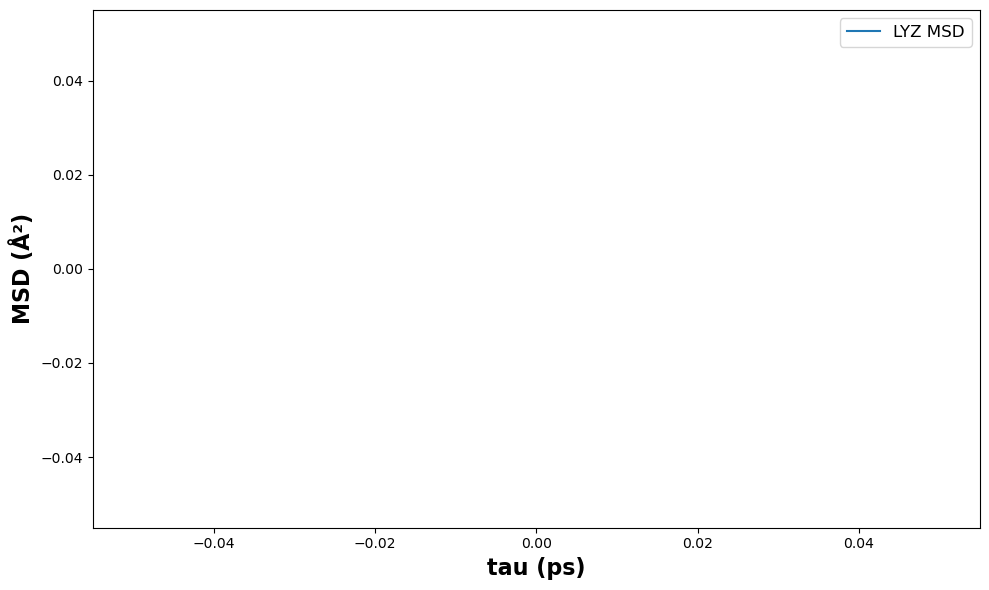

In [2]:
plt.ion()  # Turn on interactive mode
fig, ax = plt.subplots(figsize=(10, 6))
p_total, = ax.plot([], [], label='LYZ MSD')
ax.set_xlabel('tau (ps)', fontsize=16, fontweight='bold', color='black')
ax.set_ylabel('MSD (Å²)', fontsize=16, fontweight='bold', color='black')
#ax.set_xticklabels([])
#ax.set_yticklabels([])
ax.legend(fontsize=12)
plt.tight_layout()
#display(fig)

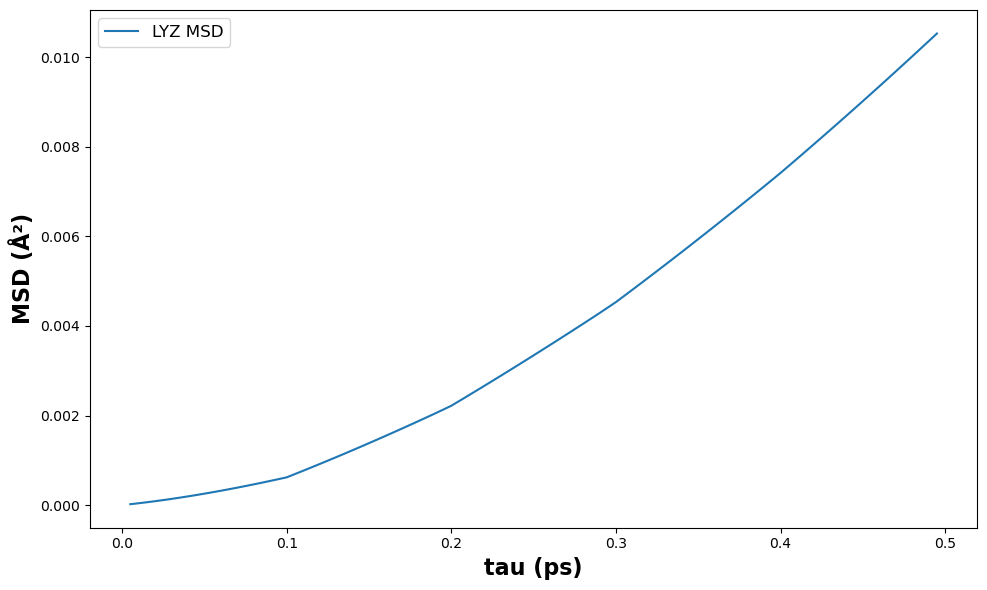

In [ ]:
try:
    #Connect to IMD server and set up analysis
    u = mda.Universe("mda.tpr", "imd://localhost:8891")
    protein = u.select_atoms("protein")
    
    #Create NoJump transformation
    nojump = mda.transformations.NoJump()
    
except Exception as e:
    print(f"Error during connection: {e}")
else:
    try:
        frame_count = 0
        dt = 5  #timestep in fs
        window_size = 100  #Keep exactly 100 frames
        
        # Initialize buffer as numpy array
        com_positions = np.zeros((window_size, 3))  #(100, 3) for x,y,z coordinates
        window_ready = False  #Flag to track when analysis window is ready
        
        #Pre-define tau values for plotting
        tau_frames = np.arange(1, window_size)
        tau_ps = tau_frames * dt * 1e-3  #Convert to picoseconds
        
        #Cumulative sum of MSD values for averaging
        msd_sum = np.zeros(window_size - 1)
        n_samples = 0  #Number of MSD samples collected

        #Main analysis loop
        for ts in u.trajectory:
            try:
                #Apply NoJump transformation to the current timestep
                ts = nojump(ts)
                
                #Get center of mass of protein after NoJump
                com_position = protein.center_of_mass()
                #print(f"Frame {frame_count}: COM position = {com_position}")
                
                #FIFO buffer logic using np.roll
                com_positions = np.roll(com_positions, -1, axis=0)
                com_positions[-1] = com_position  #Add new position at the end
                #print(f"Buffer first position: {com_positions[0]}")
                #print(f"Buffer last position: {com_positions[-1]}")
                
                if frame_count >= window_size - 1:  #Window has enough frames
                    window_ready = True
                
                #Calculate MSD when window is ready
                if window_ready:
                    #Use the last frame as reference
                    current_pos = com_positions[-1]
                    
                    #Calculate MSD
                    displacements = current_pos - com_positions[:-1]  #All past positions at once
                    msd_values = np.sum(displacements**2, axis=1)[::-1]  #Sum across x,y,z and reverse the order of array so that MSD of lowest tau value is first
                    
                    #Add to cumulative sum
                    msd_sum += msd_values
                    n_samples += 1
                    
                    #Calculate time-averaged MSD
                    msd_avg = msd_sum / n_samples
                    
                    # Update plot every 100 frames
                    if frame_count % 100 == 0:
                        p_total.set_data(tau_ps, msd_avg)
                        ax.relim()
                        ax.autoscale_view()
                        clear_output(wait=True)
                        display(fig)
                
                frame_count += 1
                
            except Exception as e:
                print(f"Error in frame {frame_count}: {str(e)}")
                continue
              
    finally:
        u.trajectory.close()